In [87]:
device="cuda"

In [88]:
import numpy as np
import copy
from packboost.core import PackBoost
import time

np.random.seed(42)
X = np.random.randint(0, 4, (100000, 20), dtype='i1')
Xval = np.random.randint(0, 4, (200, 20), dtype='i1')
X_test = np.random.randint(0, 4, (1000, 20), dtype='i1')

def make_y(X_):
    # Spread signal across many dimensions with small interaction terms
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        - 0.22 * X_[:, 2].astype('f4')
        + 0.18 * X_[:, 3].astype('f4')
        + 0.14 * X_[:, 4].astype('f4')
        - 0.10 * X_[:, 5].astype('f4')
        + 0.08 * X_[:, 6].astype('f4')
        + 0.05 * X_[:, 7].astype('f4')
        + 0.03 * X_[:, 8].astype('f4')
        - 0.02 * X_[:, 9].astype('f4')
        + 0.01 * (X_[:, 0] * X_[:, 4]).astype('f4')
        - 0.01 * (X_[:, 2] * X_[:, 6]).astype('f4')
        + 0.10 * np.random.randn(len(X_)).astype('f4')
    )

y    = make_y(X)
yval = make_y(Xval)
y_test_true = make_y(X_test)

model = PackBoost(device=device)
start = time.time()
model.fit(
    X, y,
    Xv=Xval, Yv=yval,
    rounds=20,
    max_depth=8,
    nfolds=2,
    lr=1.0,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

Training completed in 0.09 seconds


In [89]:
# model_gpu = copy.deepcopy(model)
# model_gpu.device = 'cuda'
# preds_gpu = model_gpu.predict(X_test)
# preds_gpu

model.V

tensor([[[     4787,     18546,     72340,  ...,         0,         0,
                  0],
         [    18499,      4834,     19003,  ...,         0,         0,
                  0]],

        [[     5324,     18015,     12958,  ...,         0,         0,
                  0],
         [     4275,     19049,     17272,  ...,         0,         0,
                  0]],

        [[     5323,     18012,     14643,  ...,         0,         0,
                  0],
         [     4785,     18542,     16065,  ...,         0,         0,
                  0]],

        ...,

        [[     3443,     16111,     11954,  ...,  -2144193,   9187957,
          -18296644],
         [     3941,     15620,     10505,  ...,  -5153222,  10087294,
          -20252714]],

        [[     3943,     15338,     11956,  ...,         0,  11380313,
           -4315666],
         [    15626,      3651,     14316,  ...,         0,   8707600,
          -11494768]],

        [[    15384,      3599,     13750,  ..

In [90]:
model.I

tensor([[[ 6,  0,  0,  ...,  0,  0,  0],
         [ 0,  6,  0,  ...,  0,  0,  0]],

        [[18,  2,  4,  ...,  0,  0,  0],
         [ 2, 20, 18,  ...,  0,  0,  0]],

        [[18,  6, 20,  ...,  0,  0,  0],
         [ 6, 18, 44,  ...,  0,  0,  0]],

        ...,

        [[ 2,  6,  8,  ..., 26, 21,  8],
         [ 6,  2, 20,  ..., 20, 20, 20]],

        [[ 6,  6,  8,  ...,  0,  0,  8],
         [ 0, 34,  0,  ...,  0,  0,  0]],

        [[ 0, 10,  8,  ..., 50, 26,  0],
         [ 8,  0,  6,  ...,  0,  0, 37]]], device='cuda:0', dtype=torch.uint16)

In [91]:
model_cpu = copy.deepcopy(model)
model_cpu.V = model_cpu.V.cpu()
model_cpu.I = model_cpu.I.cpu()
# Ensure tensors are on CPU
model_cpu.device = 'cpu'
preds_cpu = model_cpu.predict(X_test)
preds_cpu

array([ 0.1786438 ,  0.1456252 ,  0.14050345,  0.16210201,  0.15310317,
        0.27064946,  0.13070701,  0.16694126,  0.07825956,  0.11936971,
        0.13599353,  0.14403541,  0.18393278,  0.15151435,  0.19632515,
        0.20025243,  0.13720253,  0.10623148,  0.12825757,  0.179477  ,
        0.15614976,  0.17071748,  0.054101  ,  0.18130419,  0.07755824,
        0.15416732,  0.12386248,  0.14930713,  0.08848736,  0.13595265,
        0.08981713,  0.03160335,  0.11512174,  0.127155  ,  0.23297556,
        0.0686909 ,  0.08170944,  0.16600615,  0.2219207 ,  0.06332865,
        0.20289521,  0.22446826,  0.13094492,  0.11165629,  0.14129397,
        0.08539978,  0.09473332,  0.07157209,  0.11841816,  0.13306938,
        0.08268954,  0.16834873,  0.07679512,  0.18577206,  0.19393203,
        0.1370518 ,  0.15529625,  0.18536149,  0.14630182,  0.18416025,
        0.09272516,  0.07264671,  0.1460058 ,  0.17268935,  0.15617466,
        0.25875878,  0.16882652,  0.22045948,  0.05737557,  0.15

## compare cpu vs gpu P

In [92]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.hist(preds_gpu, bins=50, alpha=0.5, label='GPU', color='blue', edgecolor='black')
# plt.xlabel('Prediction Value')
# plt.ylabel('Frequency')
# plt.title('GPU vs CPU Predictions Distribution')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

Pearson r : -0.2096
R²        : -2.3639


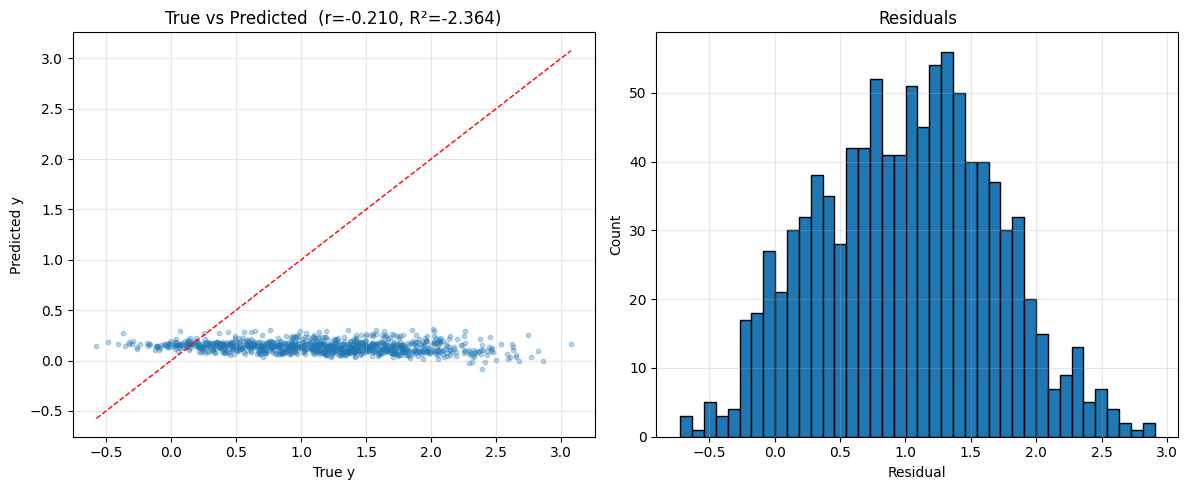

In [93]:
import matplotlib.pyplot as plt

preds = model_cpu.predict(X_test)
corr = np.corrcoef(preds, y_test_true)[0, 1]
ss_res = np.sum((y_test_true - preds) ** 2)
ss_tot = np.sum((y_test_true - y_test_true.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f"Pearson r : {corr:.4f}")
print(f"R²        : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_true, preds, alpha=0.3, s=10)
lo, hi = y_test_true.min(), y_test_true.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_xlabel("True y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title(f"True vs Predicted  (r={corr:.3f}, R²={r2:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_test_true - preds, bins=40, edgecolor='black')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()